In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import joblib

d:\Downloads\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\Downloads\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [5]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    
    mels = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mels_db = librosa.power_to_db(mels, ref=np.max)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    
    zcr = librosa.feature.zero_crossing_rate(y)
    
    rms = librosa.feature.rms(y=y)
    
    y_harmonic, _ = librosa.effects.hpss(y)
    chroma = librosa.feature.chroma_stft(y=y_harmonic, sr=sr)
    
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    return np.hstack([
        np.mean(mels_db, axis=1), np.std(mels_db, axis=1),
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(zcr, axis=1), np.std(zcr, axis=1),
        np.mean(rms, axis=1), np.std(rms, axis=1),
        np.mean(chroma, axis=1), np.std(chroma, axis=1),
        np.mean(centroid, axis=1), np.std(centroid, axis=1)
    ])

In [6]:
def process_emotion_folders(base_path):
    X, y = [], []
    
    emotion_dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    for emotion_label in tqdm(emotion_dirs, desc="Processing emotions"):
        emotion_path = os.path.join(base_path, emotion_label)
        
        files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
        
        for file in files:
            file_path = os.path.join(emotion_path, file)
            
            features = extract_features(file_path)
            if features is not None:
                X.append(features)
                y.append(emotion_label)
                
    return np.array(X), np.array(y)

In [7]:
path = "Emotions" 

In [8]:
data_info = {}

for emotion in os.listdir(path):
    emotion_folder = os.path.join(path, emotion)
    if os.path.isdir(emotion_folder):
        count = len(os.listdir(emotion_folder))
        data_info[emotion] = count

df_dist = pd.DataFrame(list(data_info.items()), columns=['Emotion', 'Count'])
df_dist = df_dist.sort_values(by='Count', ascending=False)
df_dist

,Emotion,Count
0,Angry,2167
3,Happy,2167
5,Sad,2167
2,Fearful,2047
1,Disgusted,1863
4,Neutral,1795
6,Suprised,592


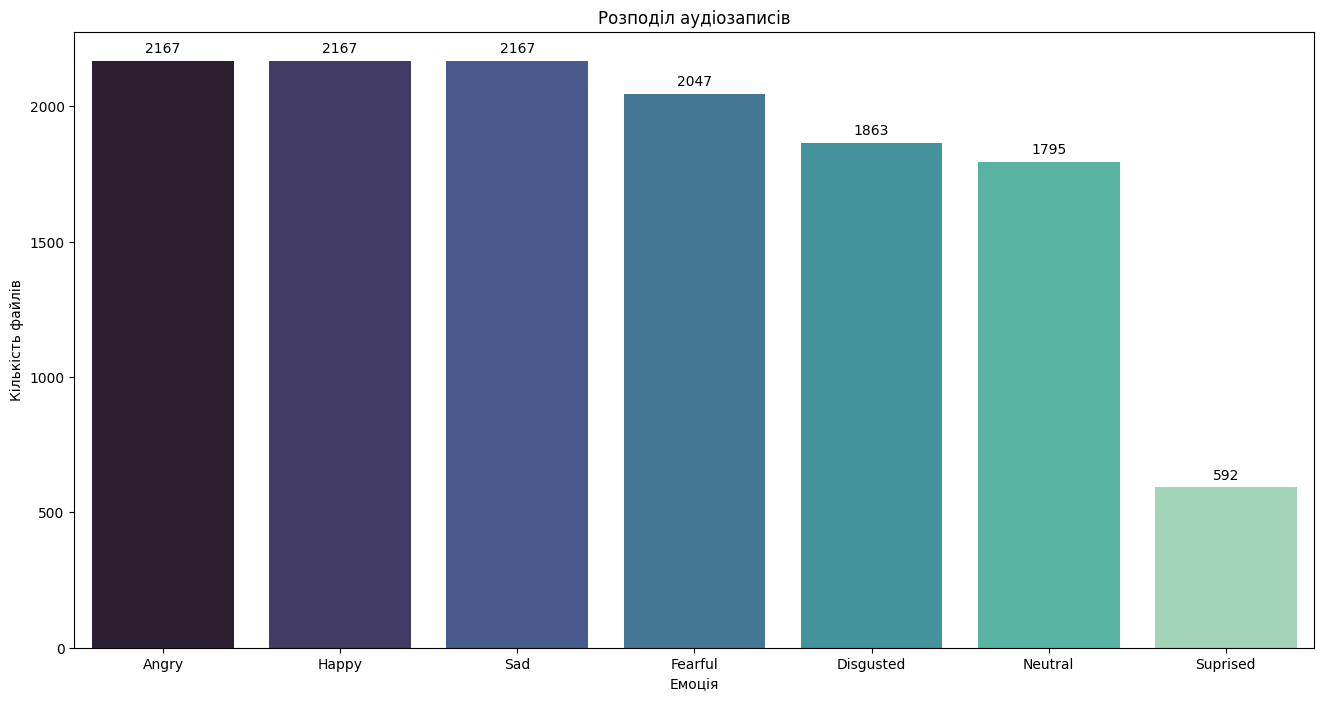

In [9]:
f, ax = plt.subplots(1, 1, figsize = (16, 8))

sns.barplot(
    data = df_dist,
    x = 'Emotion', 
    y = 'Count', 
    hue = 'Emotion',
    palette = 'mako',
    ax = ax,
    legend = False
    )

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

ax.set(title = 'Розподіл аудіозаписів', xlabel = 'Емоція', ylabel = 'Кількість файлів')
plt.show()

In [10]:
X_raw, y_raw = process_emotion_folders(path)

Processing emotions:   0%|          | 0/7 [00:00<?, ?it/s]d:\Downloads\anaconda\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
d:\Downloads\anaconda\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,
Processing emotions:  71%|███████▏  | 5/7 [41:04<16:07, 483.79s/it]d:\Downloads\anaconda\Lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Processing emotions: 100%|██████████| 7/7 [52:06<00:00, 446.67s/it]


In [11]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=66, stratify=y_raw)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [13]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

In [14]:
feature_names = ([f'mel_mean_{i}' for i in range(128)] + 
    [f'mel_std_{i}' for i in range(128)] +
    
    [f'mfcc_mean_{i}' for i in range(40)] + 
    [f'mfcc_std_{i}' for i in range(40)] +
    
    ['zcr_mean', 'zcr_std'] + 
    ['rms_mean', 'rms_std'] +
    
    [f'chroma_mean_{i}' for i in range(12)] + 
    [f'chroma_std_{i}' for i in range(12)] +
    
    ['centroid_mean', 'centroid_std'])

X_train_df.columns = feature_names

In [15]:
X_test_df.columns = X_train_df.columns

In [16]:
X_train_df.head()

,mel_mean_0,mel_mean_1,mel_mean_2,mel_mean_3,mel_mean_4,mel_mean_5,mel_mean_6,mel_mean_7,mel_mean_8,mel_mean_9,...,chroma_std_4,chroma_std_5,chroma_std_6,chroma_std_7,chroma_std_8,chroma_std_9,chroma_std_10,chroma_std_11,centroid_mean,centroid_std
0,0.249643,0.340553,0.332555,0.330376,0.198349,0.319942,0.403080,0.498186,0.560844,0.454626,...,0.667246,-0.715444,0.171343,0.915670,-1.101897,-0.267045,-0.632302,-0.920292,-0.133968,-0.191158
1,-2.521272,-2.107137,-1.804872,-1.965893,-2.175089,-2.418848,-2.356978,-2.164807,-1.659741,-1.062788,...,0.640033,0.206668,0.659272,0.073581,0.437086,0.557308,1.092640,1.254339,1.900226,2.081878
2,-1.049961,-1.199944,-1.128658,-1.123573,-1.390247,-1.325401,-0.839548,-0.388418,-0.440524,-0.662916,...,-1.037835,-1.085668,1.018841,1.293827,0.062466,-0.619328,0.671820,0.442385,0.502224,0.916147
3,-0.106054,0.130465,0.214844,0.290852,0.208622,-0.098690,-0.093885,0.025318,0.181466,0.389560,...,-0.417686,-1.590658,-1.071052,0.895404,-0.187588,-1.960855,1.125953,0.420888,-0.280174,-0.471134
4,1.474327,1.605818,1.487533,1.449590,1.472213,1.444493,1.224785,1.243166,1.376838,1.430714,...,-1.470888,-1.180402,-0.182274,-0.785183,-0.429685,0.050312,-0.158227,-0.463257,-0.710430,-0.850785


In [17]:
X_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10238 entries, 0 to 10237
Columns: 366 entries, mel_mean_0 to centroid_std
dtypes: float64(366)
memory usage: 28.6 MB


In [18]:
X_train_df.nunique()

mel_mean_0       10230
mel_mean_1       10228
mel_mean_2       10227
mel_mean_3       10230
mel_mean_4       10231
                 ...  
chroma_std_9     10227
chroma_std_10    10223
chroma_std_11    10228
centroid_mean    10234
centroid_std     10234
Length: 366, dtype: int64

In [19]:
print("null values in variables:")
X_train_df.isna().sum()

null values in variables:


mel_mean_0       0
mel_mean_1       0
mel_mean_2       0
mel_mean_3       0
mel_mean_4       0
                ..
chroma_std_9     0
chroma_std_10    0
chroma_std_11    0
centroid_mean    0
centroid_std     0
Length: 366, dtype: int64

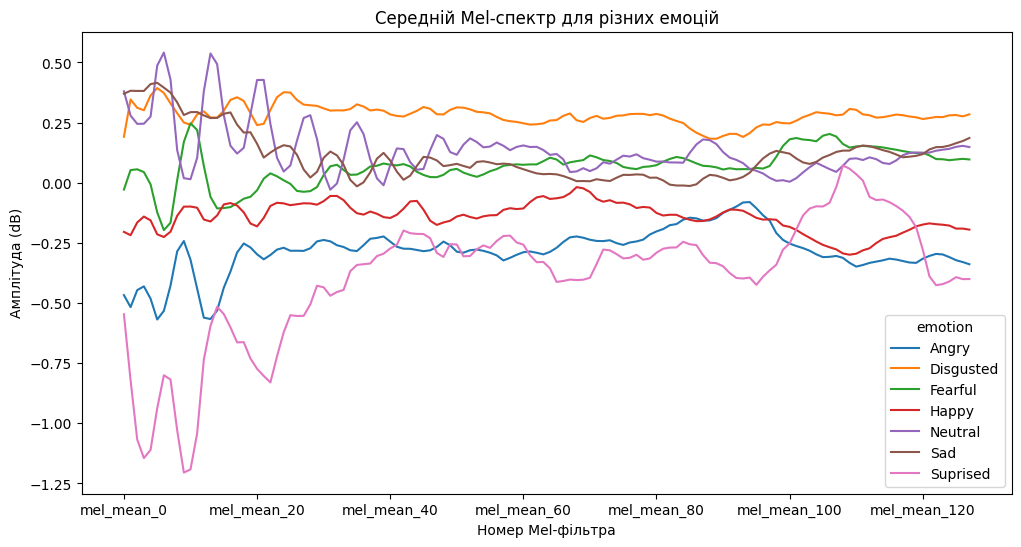

In [20]:
f, ax = plt.subplots(1, 1, figsize = (12, 6))

mel_means = X_train_df.iloc[:, :128]
mel_means['emotion'] = y_train

mel_means.groupby('emotion').mean().T.plot(ax = ax)
ax.set_title("Середній Mel-спектр для різних емоцій")
ax.set_xlabel("Номер Mel-фільтра")
ax.set_ylabel("Амплітуда (dB)")
plt.show()

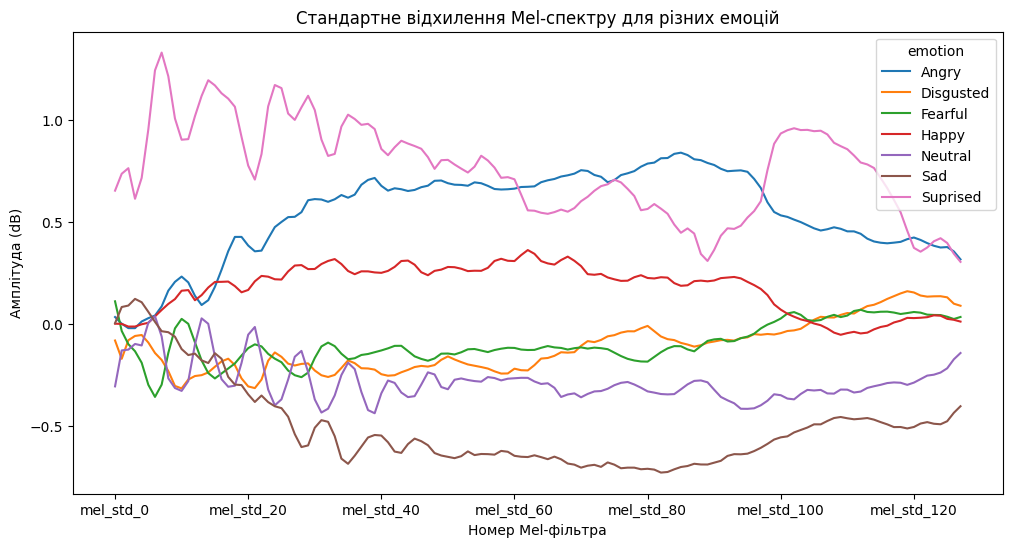

In [21]:
f, ax = plt.subplots(1, 1, figsize = (12, 6))

mel_std = X_train_df.iloc[:, 128:256]
mel_std['emotion'] = y_train

mel_std.groupby('emotion').mean().T.plot(ax = ax)
ax.set_title("Стандартне відхилення Mel-спектру для різних емоцій")
ax.set_xlabel("Номер Mel-фільтра")
ax.set_ylabel("Амплітуда (dB)")
plt.show()

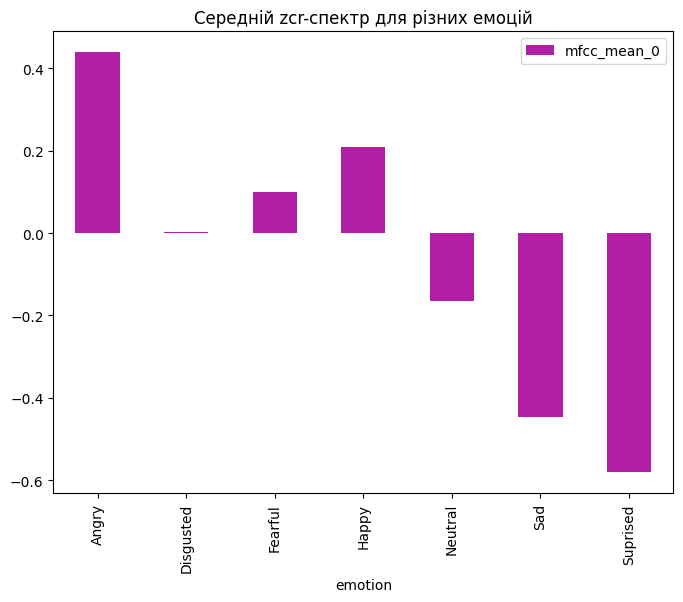

In [22]:
f, ax = plt.subplots(1, 1, figsize = (8, 6))

X_train_df.iloc[:, 256:257].assign(emotion=y_train).groupby('emotion').mean().plot(kind='bar', color = "#B31EA6", ax = ax)
ax.set_title("Середній zcr-спектр для різних емоцій")

plt.show()

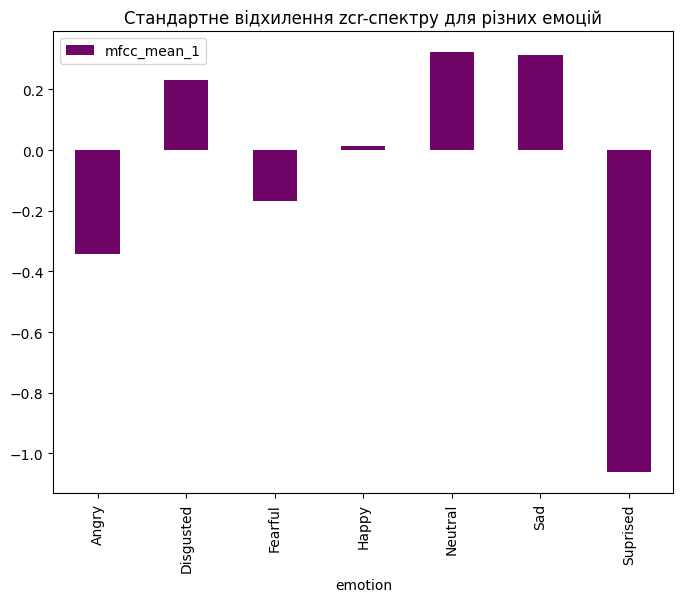

In [23]:
f, ax = plt.subplots(1, 1, figsize = (8, 6))

X_train_df.iloc[:, 257:258].assign(emotion=y_train).groupby('emotion').mean().plot(kind='bar', color = '#700567', ax = ax)
ax.set_title("Стандартне відхилення zcr-спектру для різних емоцій")

plt.show()

In [24]:
print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Train set size: 10238
Test set size: 2560


In [25]:
y_train_df.head(10)

,0
0,Happy
1,Happy
2,Happy
3,Angry
4,Sad
5,Angry
6,Disgusted
7,Fearful
8,Sad
9,Sad


In [26]:
y_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10238 entries, 0 to 10237
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       10238 non-null  str  
dtypes: str(1)
memory usage: 139.9 KB


In [27]:
pd.concat([y_train_df.value_counts(), y_test_df.value_counts()], axis=1, ignore_index=True).rename(
    columns={0: "Train", 1: "Test"}
)

,Train,Test
0,,
Happy,1734,433
Angry,1733,434
Sad,1733,434
Fearful,1638,409
Disgusted,1490,373
Neutral,1436,359
Suprised,474,118


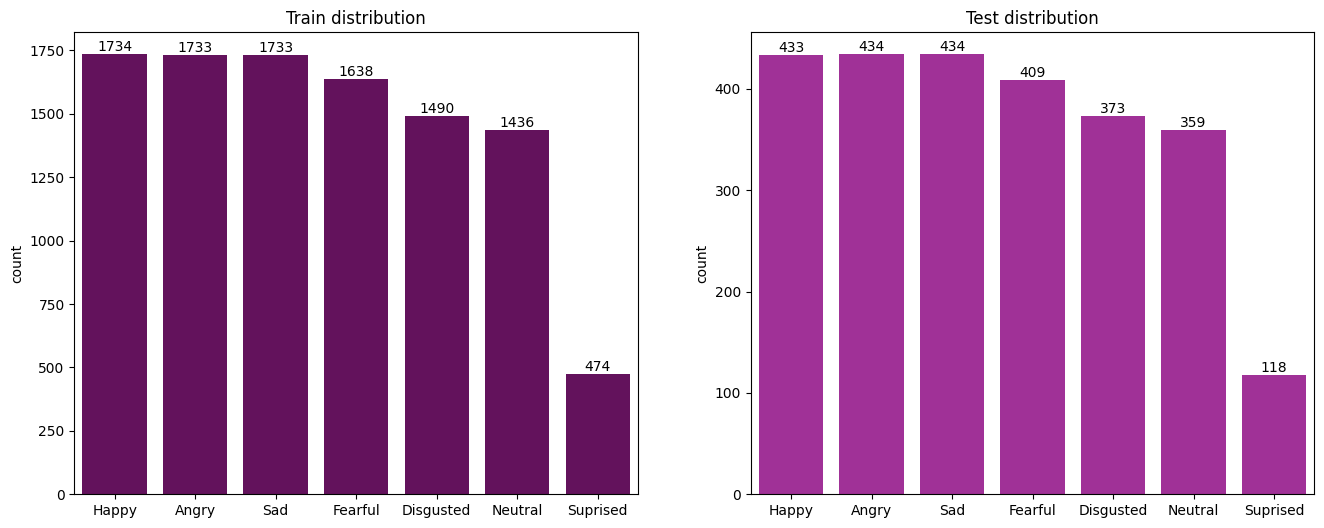

In [28]:
f, axs = plt.subplots(1, 2, figsize=(16, 6))

common_order = pd.Series(y_train).value_counts().index

sns.countplot(
    x=y_train,
    color='#700567',
    ax=axs[0],
    order=common_order
)

sns.countplot(
    x=y_test,
    color="#B31EA6",
    ax=axs[1],
    order=common_order
)

axs[0].set_title("Train distribution")
axs[1].set_title("Test distribution")

axs[0].bar_label(axs[0].containers[0])
axs[1].bar_label(axs[1].containers[0])
plt.show()

In [29]:
mi_score = pd.Series(
    mutual_info_classif(X_train_df, y_train), 
    index=X_train_df.columns
)
mi_score.sort_values(ascending=False)

mel_mean_3       0.220215
rms_mean         0.218164
mel_mean_4       0.215988
mel_mean_9       0.206442
rms_std          0.204366
                   ...   
mfcc_mean_12     0.025372
mfcc_mean_13     0.023670
chroma_mean_1    0.021425
chroma_mean_3    0.016886
chroma_mean_4    0.013451
Length: 366, dtype: float64

In [30]:
sgd = SGDClassifier(random_state=66, max_iter=1000, tol=1e-3)

param_sgd = {
    "loss": ['hinge', 'log_loss'], # hinge - svm, log_loss - логістична регресія
    "alpha": [0.001, 0.01, 0.1], # чим вище альфа, тим сильніша регуляризація
    "penalty": ['l2', 'l1', 'elasticnet'], # тип регуляризації
    "class_weight": ['balanced'] # баланс між класами
}

In [31]:
random_sgd = RandomizedSearchCV(sgd, param_sgd, cv=5, random_state=66)
random_sgd.fit(X_train_df, y_train)
print("best SGD params:", random_sgd.best_params_)

d:\Downloads\anaconda\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\Downloads\anaconda\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


best SGD params: {'penalty': 'elasticnet', 'loss': 'hinge', 'class_weight': 'balanced', 'alpha': 0.001}


In [32]:
y_pred_sgd = random_sgd.predict(X_test_df)

In [33]:
print("SGD classification report:\n", classification_report(y_test, y_pred_sgd))

SGD classification report:
               precision    recall  f1-score   support

       Angry       0.71      0.68      0.69       434
   Disgusted       0.46      0.58      0.51       373
     Fearful       0.60      0.48      0.53       409
       Happy       0.59      0.54      0.56       433
     Neutral       0.57      0.52      0.54       359
         Sad       0.64      0.70      0.67       434
    Suprised       0.66      0.82      0.73       118

    accuracy                           0.60      2560
   macro avg       0.60      0.62      0.61      2560
weighted avg       0.60      0.60      0.60      2560



In [34]:
os.environ['LOKY_MAX_CPU_COUNT'] = '6'

In [35]:
knn = KNeighborsClassifier()

param_grid_knn = {
    "n_neighbors": [5, 7, 9, 11],
    "weights": ['uniform', 'distance']# важливість сусідів
}

In [36]:
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5)
grid_knn.fit(X_train_df, y_train)
print("best KNN params:", grid_knn.best_params_)

best KNN params: {'n_neighbors': 11, 'weights': 'distance'}


In [37]:
y_pred_knn = grid_knn.predict(X_test_df)

In [38]:
print("KNN classification report:\n", classification_report(y_test, y_pred_knn))

KNN classification report:
               precision    recall  f1-score   support

       Angry       0.68      0.79      0.74       434
   Disgusted       0.52      0.54      0.53       373
     Fearful       0.64      0.50      0.56       409
       Happy       0.67      0.56      0.61       433
     Neutral       0.59      0.60      0.60       359
         Sad       0.63      0.69      0.66       434
    Suprised       0.77      0.93      0.85       118

    accuracy                           0.63      2560
   macro avg       0.64      0.66      0.65      2560
weighted avg       0.63      0.63      0.63      2560



In [39]:
rf = RandomForestClassifier(class_weight='balanced', random_state=66)

param_rf = {
    "n_estimators": [200, 300, 500], # більше дерев — стабільніший результат
    "max_depth": [15, 20, 25],  # глибокі дерева
    "min_samples_leaf": [2, 4], # чим менше, тим більше деталей
    "criterion": ["gini", "entropy", "log_loss"] # різні критерії якості розбиття
}

In [40]:
random_rf = RandomizedSearchCV(rf, param_rf, cv=3, n_jobs=-1, random_state=66)
random_rf.fit(X_train_df, y_train)
print("best Random Forest params:", random_rf.best_params_)

best Random Forest params: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_depth': 25, 'criterion': 'log_loss'}


In [41]:
y_pred_rf = random_rf.predict(X_test_df)

In [42]:
print("Random Forest classification report:\n", classification_report(y_test, y_pred_rf))

Random Forest classification report:
               precision    recall  f1-score   support

       Angry       0.70      0.81      0.75       434
   Disgusted       0.62      0.46      0.53       373
     Fearful       0.78      0.47      0.59       409
       Happy       0.63      0.63      0.63       433
     Neutral       0.57      0.70      0.63       359
         Sad       0.64      0.76      0.70       434
    Suprised       0.85      0.96      0.90       118

    accuracy                           0.66      2560
   macro avg       0.68      0.69      0.68      2560
weighted avg       0.67      0.66      0.65      2560



In [43]:
def compare_models(models, x_test, y):
    results = []
    
    for name, model in models.items():
        y_pred = model.predict(x_test)
        
        results.append({
            "model": name,
            "accuracy": accuracy_score(y, y_pred), # загальна точність (не варто орієнтуватись при дисбалансі класів)
            "precision": precision_score(y, y_pred, average='macro'), # оцінка правильних позитивних прогнозів серед всіх позитивних прогнозів
            "recall": recall_score(y, y_pred, average='macro'), # оцінка правильних позитивних прогнозів серед всіх позитивних випадків
            "f1": f1_score(y, y_pred, average='macro'), # оцінка на основі попередніх двох
        })
    
    return pd.DataFrame(results).set_index("model")

In [44]:
models = {
    "SGD": random_sgd.best_estimator_,
    "KNN": grid_knn.best_estimator_,
    "RF": random_rf.best_estimator_
}

compare_models(models, X_test_df, y_test)

,accuracy,precision,recall,f1
model,,,,
SGD,0.596484,0.603836,0.616763,0.606408
KNN,0.633203,0.643879,0.660474,0.648587
RF,0.659766,0.683964,0.686335,0.675268


In [46]:
joblib.dump(models['RF'], 'emotion_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Модель та scaler успішно збережені")

Модель та scaler успішно збережені
